In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import cv2

print("Setup done")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup done


In [2]:
real_path = "/content/drive/MyDrive/Research Paper/extracted_dataset/Dastset/Real"
fake_path = "/content/drive/MyDrive/Research Paper/extracted_dataset/Dastset/Fake"

print("Real:", len(os.listdir(real_path)))
print("Fake:", len(os.listdir(fake_path)))

Real: 7492
Fake: 5124


In [3]:
def load_images(folder, label, limit=3000):
    data, labels = [], []

    for i, img_name in enumerate(os.listdir(folder)):
        if i >= limit:
            break

        path = os.path.join(folder, img_name)
        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.resize(img, (96, 96))   # UPDATED
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        data.append(img)
        labels.append(label)

    return data, labels

real_data, real_labels = load_images(real_path, 0)
fake_data, fake_labels = load_images(fake_path, 1)

X = np.array(real_data + fake_data)
y = np.array(real_labels + fake_labels)

print("Total:", len(X))


Total: 5998


In [4]:
from sklearn.utils import resample

real_X = X[y == 0]
fake_X = X[y == 1]

real_y = y[y == 0]
fake_y = y[y == 1]

real_X_down, real_y_down = resample(
    real_X, real_y,
    replace=False,
    n_samples=len(fake_X),
    random_state=42
)

X_balanced = np.concatenate((real_X_down, fake_X))
y_balanced = np.concatenate((real_y_down, fake_y))

print("Balanced:", len(X_balanced))

Balanced: 5998


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42
)

In [6]:
from skimage.feature import local_binary_pattern
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

def extract_lbp(images):
    features = []

    for img in images:
        gray = cv2.cvtColor(img.astype('uint8'), cv2.COLOR_RGB2GRAY)
        lbp = local_binary_pattern(gray, 24, 3, method="uniform")

        hist, _ = np.histogram(lbp.ravel(),
                               bins=np.arange(0, 27),
                               range=(0, 26))

        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)

        features.append(hist)

    return np.array(features)

X_lbp = extract_lbp(X_balanced)

scaler = StandardScaler()
X_lbp = scaler.fit_transform(X_lbp)

X_train_lbp, X_test_lbp, y_train_lbp, y_test_lbp = train_test_split(
    X_lbp, y_balanced, test_size=0.2, random_state=42
)

# IMPROVED: Better SVM hyperparameters
svm = SVC(kernel='rbf', C=50, gamma=0.01, probability=True)
svm.fit(X_train_lbp, y_train_lbp)

y_pred = svm.predict(X_test_lbp)
lbp_acc = accuracy_score(y_test_lbp, y_pred)

print("LBP + SVM:", lbp_acc)

LBP + SVM: 0.6233333333333333


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# IMPROVED: More aggressive augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.4,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    shear_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    fill_mode='nearest'
)

# ⚠️ fit only on normalized data later

X_train_cnn = X_train / 255.0
X_test_cnn = X_test / 255.0

datagen.fit(X_train_cnn)

In [8]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# datagen = ImageDataGenerator(
#     rotation_range=25,
#     zoom_range=0.3,
#     horizontal_flip=True,
#     brightness_range=[0.8, 1.2]
# )

# # ⚠️ fit only on normalized data later

In [9]:

# X_train_cnn = X_train / 255.0
# X_test_cnn = X_test / 255.0

# datagen.fit(X_train_cnn)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# IMPROVED: Deeper CNN with more filters and better regularization
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3), padding='same'),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

# IMPROVED: More epochs with better training
cnn.fit(
    datagen.flow(X_train_cnn, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test_cnn, y_test),
    verbose=1
)

_, cnn_acc = cnn.evaluate(X_test_cnn, y_test)
print("CNN:", cnn_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.5013 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.8037
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.4940 - loss: 0.6944 - val_accuracy: 0.5058 - val_loss: 0.6931
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.5115 - loss: 0.6931 - val_accuracy: 0.4925 - val_loss: 0.6954
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.5004 - loss: 0.6938 - val_accuracy: 0.4925 - val_loss: 0.6933
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.4948 - loss: 0.6932 - val_accuracy: 0.4925 - val_loss: 1.4309
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.5017 - loss: 0.6934 - val_accuracy: 0.4917 - val_loss: 2.4256
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.4902 - loss: 0.6942 - val_accuracy: 0.5075 - val_loss: 0.6931
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.4987 - loss: 0.6933 - val_accu

In [11]:

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

X_train_m = preprocess_input(X_train.copy())
X_test_m = preprocess_input(X_test.copy())

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

# IMPROVED: Unfreeze more layers for better fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

model.fit(
    datagen.flow(X_train_m, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test_m, y_test),
    callbacks=[early_stop],
    verbose=1
)

_, mobilenet_acc = model.evaluate(X_test_m, y_test)

print("MobileNet:", mobilenet_acc)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 85s 487ms/step - accuracy: 0.5952 - loss: 0.7288 - val_accuracy: 0.6617 - val_loss: 0.6064
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 75s 499ms/step - accuracy: 0.6701 - loss: 0.6226 - val_accuracy: 0.6575 - val_loss: 0.6888
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 511ms/step - accuracy: 0.7082 - loss: 0.5799 - val_accuracy: 0.6900 - val_loss: 0.6268
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 76s 508ms/step - accuracy: 0.7316 - loss: 0.5458 - val_accuracy: 0.6958 - val_loss: 0.6236
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 73s 483ms/step - accuracy: 0.7430 - loss: 0.5169 - val_accuracy: 0.7500 - val_loss: 0.5146
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 475ms/step - accuracy: 0.7584 - loss: 0.5057 - val_accuracy: 0.7717 - val_loss: 0.4687
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 512ms/step - accuracy: 0.7630 - loss: 0.4865 - val_accuracy: 0.7950 - val_loss: 0.4498
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━

In [12]:
print("\nFINAL RESULTS (Individual Models)")
print("LBP + SVM:", lbp_acc)
print("CNN:", cnn_acc)
print("MobileNet:", mobilenet_acc)

# ENSEMBLE: Combine predictions from all three models
print("\n" + "="*50)
print("ENSEMBLE VOTING RESULTS")
print("="*50)

# Get predictions from all models
svm_probs = svm.predict_proba(X_test_lbp)[:, 1]
cnn_probs = cnn.predict(X_test_cnn)
mobilenet_probs = model.predict(X_test_m)

# Ensemble methods
ensemble_avg = (svm_probs + cnn_probs.flatten() + mobilenet_probs.flatten()) / 3
ensemble_pred_avg = (ensemble_avg > 0.5).astype(int)
ensemble_acc_avg = accuracy_score(y_test, ensemble_pred_avg)

# Weighted ensemble (prioritize stronger models)
ensemble_weighted = (0.2 * svm_probs + 0.3 * cnn_probs.flatten() + 0.5 * mobilenet_probs.flatten())
ensemble_pred_weighted = (ensemble_weighted > 0.5).astype(int)
ensemble_acc_weighted = accuracy_score(y_test, ensemble_pred_weighted)

print(f"Simple Average Ensemble: {ensemble_acc_avg:.4f}")
print(f"Weighted Ensemble: {ensemble_acc_weighted:.4f}")

# BEST result
best_acc = max(lbp_acc, cnn_acc, mobilenet_acc, ensemble_acc_avg, ensemble_acc_weighted)
print(f"\nBEST ACCURACY: {best_acc:.4f}")


FINAL RESULTS (Individual Models)
LBP + SVM: 0.6233333333333333
CNN: 0.4925000071525574
MobileNet: 0.8241666555404663

ENSEMBLE VOTING RESULTS
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 564ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step
Simple Average Ensemble: 0.8075
Weighted Ensemble: 0.8200

BEST ACCURACY: 0.8242


In [13]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [14]:
y_pred_mobilenet = (model.predict(X_test_m) > 0.5).astype(int).flatten()

38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step


In [15]:
cm = confusion_matrix(y_test, y_pred_mobilenet)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[516  93]
 [118 473]]


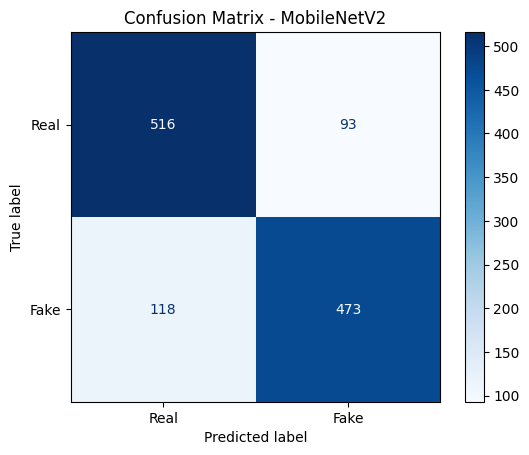

In [16]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

In [17]:
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

precision = precision_score(y_test, y_pred_mobilenet)
recall = recall_score(y_test, y_pred_mobilenet)
f1 = f1_score(y_test, y_pred_mobilenet)
accuracy = accuracy_score(y_test, y_pred_mobilenet)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", accuracy)

Precision: 0.8356890459363958
Recall: 0.8003384094754653
F1 Score: 0.8176318063958513
Accuracy: 0.8241666666666667
